Generated for: 08_final_evaluation.ipynb
Heart Disease Prediction — Final Evaluation
UCI Cleveland Heart Disease Dataset

---
NOTEBOOK OVERVIEW
---

This is the FINAL notebook in the heart disease prediction pipeline.
It loads the results produced by all three feature selection methods:

  - 🔵 Filter  (06_filter_feature_selection.py)
  - 🟡 Wrapper (07_wrapper_feature_selection.py)
  - 🟢 Embedded (05_embedded_feature_selection.py)

And produces a complete, head-to-head comparison against the Baseline.

What this notebook does:
-------------------------------------------------
Cell 1  — Install & Import Libraries
Cell 2  — Load All Saved Results

Cell 3  — Master Comparison Table (all methods × all models)

Cell 4  — Best Result Per Model: Which Method Won?

Cell 5  — Method-Level Summary (avg across all models)

Cell 6  — Grouped Bar Chart: All Methods vs Baseline (F1-Score)

Cell 7  — Performance Heatmaps: Side-by-Side

Cell 8  — Radar Chart: Best Embedded vs Best Wrapper vs Baseline

Cell 9  — ROC Curves: Best Model from Each Method

Cell 10 — Confusion Matrices: Best Model Per Method

Cell 11 — Recall Focus: Who Misses the Fewest Sick Patients?

Cell 12 — Feature Importance Summary Across Methods

Cell 13 — Final Ranking Table + Winner Declaration

Cell 14 — Save All Final Results

Cell 15 — Full Summary Report

---

## Cell 1 — Install & Import All Required Libraries

In [2]:
# !pip install xgboost mlxtend --quiet

# --- Core ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

# --- Models (needed for re-training on best features) ---
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from xgboost                 import XGBClassifier
from sklearn.naive_bayes     import GaussianNB
from sklearn.neural_network  import MLPClassifier

# --- Metrics ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve,
    classification_report
)
from sklearn.model_selection import cross_val_score

# --- Plot settings (consistent with all previous notebooks) ---
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print('=' * 60)
print('   FINAL EVALUATION NOTEBOOK — All Libraries Loaded!')
print('=' * 60)

   FINAL EVALUATION NOTEBOOK — All Libraries Loaded!


## Cell 2 — Load All Saved Results from saved_data/


We load everything saved by all previous notebooks:
- Preprocessed features (X_train, X_test, y_train, y_test)
- Baseline results
- Filter, Wrapper, and Embedded results + feature lists

This notebook does NOT redo any training from scratch —
it only loads what was already computed and compares everything.

In [3]:
LOAD_DIR = 'saved_data'

# --- Preprocessed data ---
X_train_scaled = joblib.load(f'{LOAD_DIR}/X_train_scaled.pkl')
X_test_scaled  = joblib.load(f'{LOAD_DIR}/X_test_scaled.pkl')
X_train_raw    = joblib.load(f'{LOAD_DIR}/X_train_raw.pkl')
X_test_raw     = joblib.load(f'{LOAD_DIR}/X_test_raw.pkl')
y_train        = joblib.load(f'{LOAD_DIR}/y_train.pkl')
y_test         = joblib.load(f'{LOAD_DIR}/y_test.pkl')
feature_names  = joblib.load(f'{LOAD_DIR}/feature_names.pkl')

# --- Baseline ---
baseline_results = joblib.load(f'{LOAD_DIR}/baseline_results.pkl')

# --- Filter results ---
filter_selected_features = joblib.load(f'{LOAD_DIR}/filter_selected_features.pkl')
X_train_filter           = joblib.load(f'{LOAD_DIR}/X_train_filter.pkl')
X_test_filter            = joblib.load(f'{LOAD_DIR}/X_test_filter.pkl')

# --- Embedded results ---
embedded_lasso_features = joblib.load(f'{LOAD_DIR}/embedded_lasso_features.pkl')
embedded_rf_features    = joblib.load(f'{LOAD_DIR}/embedded_rf_features.pkl')
embedded_union_features = joblib.load(f'{LOAD_DIR}/embedded_union_features.pkl')
results_lasso           = joblib.load(f'{LOAD_DIR}/embedded_results_lasso.pkl')
results_rf              = joblib.load(f'{LOAD_DIR}/embedded_results_rf.pkl')
results_union           = joblib.load(f'{LOAD_DIR}/embedded_results_union.pkl')
lasso_coefs             = pd.read_csv(f'{LOAD_DIR}/lasso_coefficients.csv', index_col=0).squeeze()
rf_importances          = pd.read_csv(f'{LOAD_DIR}/rf_importances.csv',     index_col=0).squeeze()

# --- Wrapper results ---
wrapper_rfe_features      = joblib.load(f'{LOAD_DIR}/wrapper_rfe_features.pkl')
wrapper_rfecv_features    = joblib.load(f'{LOAD_DIR}/wrapper_rfecv_features.pkl')
wrapper_forward_features  = joblib.load(f'{LOAD_DIR}/wrapper_forward_features.pkl')
wrapper_backward_features = joblib.load(f'{LOAD_DIR}/wrapper_backward_features.pkl')
wrapper_results_rfe       = joblib.load(f'{LOAD_DIR}/wrapper_results_rfe.pkl')
wrapper_results_rfecv     = joblib.load(f'{LOAD_DIR}/wrapper_results_rfecv.pkl')
wrapper_results_forward   = joblib.load(f'{LOAD_DIR}/wrapper_results_forward.pkl')
wrapper_results_backward  = joblib.load(f'{LOAD_DIR}/wrapper_results_backward.pkl')

# --- Convert to pandas ---
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names) if not isinstance(X_train_scaled, pd.DataFrame) else X_train_scaled
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_names) if not isinstance(X_test_scaled,  pd.DataFrame) else X_test_scaled
X_train_raw    = pd.DataFrame(X_train_raw,    columns=feature_names) if not isinstance(X_train_raw,    pd.DataFrame) else X_train_raw
X_test_raw     = pd.DataFrame(X_test_raw,     columns=feature_names) if not isinstance(X_test_raw,     pd.DataFrame) else X_test_raw
y_train        = pd.Series(y_train).reset_index(drop=True)
y_test         = pd.Series(y_test).reset_index(drop=True)
for df in [X_train_scaled, X_test_scaled, X_train_raw, X_test_raw,
           X_train_filter, X_test_filter]:
    df.reset_index(drop=True, inplace=True)

# --- Normalise model name keys across all result dicts ---
# Wrapper notebook used 'Neural Network (MLP)'; Embedded used 'Neural Network'
name_map = {'Neural Network (MLP)': 'Neural Network', 'MLP': 'Neural Network'}
def fix_keys(d):
    return {name_map.get(k, k): v for k, v in d.items()}

wrapper_results_rfe      = fix_keys(wrapper_results_rfe)
wrapper_results_rfecv    = fix_keys(wrapper_results_rfecv)
wrapper_results_forward  = fix_keys(wrapper_results_forward)
wrapper_results_backward = fix_keys(wrapper_results_backward)

# Wrapper accuracy results are raw floats (0-1), convert to %
def pct(d):
    return {k: round(v * 100, 2) if v <= 1.0 else round(v, 2) for k, v in d.items()}

wrapper_acc_rfe      = pct(wrapper_results_rfe)
wrapper_acc_rfecv    = pct(wrapper_results_rfecv)
wrapper_acc_forward  = pct(wrapper_results_forward)
wrapper_acc_backward = pct(wrapper_results_backward)

# Unified model name list (8 models, consistent naming)
MODEL_NAMES = list(baseline_results.keys())
# Replace 'Neural Network (MLP)' if present
MODEL_NAMES = [name_map.get(n, n) for n in MODEL_NAMES]
baseline_results = fix_keys(baseline_results)

print('✅ All files loaded successfully!')
print(f'   Baseline models         : {len(baseline_results)}')
print(f'   Feature names           : {len(feature_names)} total')
print(f'   Filter selected         : {len(filter_selected_features)} features')
print(f'   Embedded LASSO          : {len(embedded_lasso_features)} features')
print(f'   Embedded RF             : {len(embedded_rf_features)} features')
print(f'   Embedded Union          : {len(embedded_union_features)} features')
print(f'   Wrapper RFECV           : {len(wrapper_rfecv_features)} features')
print(f'   Wrapper Forward         : {len(wrapper_forward_features)} features')
print(f'   Wrapper Backward        : {len(wrapper_backward_features)} features')

✅ All files loaded successfully!
   Baseline models         : 8
   Feature names           : 22 total
   Filter selected         : 16 features
   Embedded LASSO          : 11 features
   Embedded RF             : 8 features
   Embedded Union          : 14 features
   Wrapper RFECV           : 18 features
   Wrapper Forward         : 8 features
   Wrapper Backward        : 8 features


## Cell 3 — Master Comparison Table: All Methods × All Models


This is the single most important table in the project.
It shows F1-Score for every model under every feature selection method.

Columns:
  Baseline | Filter | Emb-LASSO | Emb-RF | Emb-Union |
  Wrap-RFE | Wrap-RFECV | Wrap-Fwd | Wrap-Bwd

We use F1-Score as the primary metric because it balances
precision and recall — essential for medical diagnosis.

In [4]:
print('=' * 90)
print('   MASTER COMPARISON TABLE — F1-Score (%) Across All Methods')
print('=' * 90)

# --- Filter F1: rebuild from scratch using saved filter data ---
# The filter notebook saved F1 separately; we re-derive for consistency
from sklearn.linear_model    import LogisticRegression  as LR
from sklearn.tree            import DecisionTreeClassifier as DT
from sklearn.ensemble        import RandomForestClassifier as RF
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier as KNN
from xgboost                 import XGBClassifier as XGB
from sklearn.naive_bayes     import GaussianNB
from sklearn.neural_network  import MLPClassifier as MLP

def get_models():
    return {
        'Logistic Regression': LR(random_state=42, max_iter=1000),
        'Decision Tree':       DT(random_state=42, max_depth=5),
        'Random Forest':       RF(random_state=42, n_estimators=100),
        'SVM':                 SVC(random_state=42, kernel='rbf', probability=True),
        'KNN':                 KNN(n_neighbors=5),
        'XGBoost':             XGB(random_state=42, n_estimators=100,
                                   eval_metric='logloss', use_label_encoder=False),
        'Naive Bayes':         GaussianNB(),
        'Neural Network':      MLP(random_state=42, hidden_layer_sizes=(64, 32),
                                   activation='relu', max_iter=500)
    }

# Re-evaluate filter models to get full metrics
print('Re-evaluating Filter models...')
filter_full_results = {}
for name, model in get_models().items():
    model.fit(X_train_filter, y_train)
    y_pred = model.predict(X_test_filter)
    y_prob = model.predict_proba(X_test_filter)[:, 1]
    filter_full_results[name] = {
        'Accuracy' : round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0) * 100, 2),
        'Recall'   : round(recall_score(y_test, y_pred, zero_division=0) * 100, 2),
        'F1-Score' : round(f1_score(y_test, y_pred, zero_division=0) * 100, 2),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob) * 100, 2),
    }

# --- Build master table ---
rows = []
for name in MODEL_NAMES:
    # Wrapper accuracy → convert; wrapper doesn't save full metrics dict,
    # so we use what we have. For F1 we rely on re-training below.
    row = {
        'Model'       : name,
        'Baseline'    : baseline_results[name]['F1-Score'],
        'Filter'      : filter_full_results[name]['F1-Score'],
        'Emb-LASSO'   : results_lasso[name]['F1-Score'],
        'Emb-RF'      : results_rf[name]['F1-Score'],
        'Emb-Union'   : results_union[name]['F1-Score'],
        'Wrap-RFE'    : None,   # filled below
        'Wrap-RFECV'  : None,
        'Wrap-Fwd'    : None,
        'Wrap-Bwd'    : None,
    }
    rows.append(row)

# Re-train wrapper models to get F1-scores
def wrapper_f1(features, scaled=True):
    X_tr = X_train_scaled[features] if scaled else X_train_raw[features]
    X_te = X_test_scaled[features]  if scaled else X_test_raw[features]
    res = {}
    for name, model in get_models().items():
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)
        res[name] = round(f1_score(y_test, y_pred, zero_division=0) * 100, 2)
    return res

print('Re-evaluating Wrapper models (this may take ~1 min)...')

# Use LR-selected features for RFE (consistent with wrapper notebook)
rfe_features_for_eval = wrapper_rfe_features.get(
    'Logistic Regression', wrapper_rfecv_features
)

w_rfe  = wrapper_f1(rfe_features_for_eval)
w_rcv  = wrapper_f1(wrapper_rfecv_features)
w_fwd  = wrapper_f1(wrapper_forward_features)
w_bwd  = wrapper_f1(wrapper_backward_features)

for i, name in enumerate(MODEL_NAMES):
    rows[i]['Wrap-RFE']   = w_rfe[name]
    rows[i]['Wrap-RFECV'] = w_rcv[name]
    rows[i]['Wrap-Fwd']   = w_fwd[name]
    rows[i]['Wrap-Bwd']   = w_bwd[name]

master_df = pd.DataFrame(rows).set_index('Model')
method_cols = ['Baseline', 'Filter', 'Emb-LASSO', 'Emb-RF', 'Emb-Union',
               'Wrap-RFE', 'Wrap-RFECV', 'Wrap-Fwd', 'Wrap-Bwd']
master_df = master_df[method_cols]

print('\nMASTER F1-SCORE TABLE (All Methods × All Models) — %')
print('=' * 90)
display(master_df.style
    .format('{:.2f}%')
    .background_gradient(cmap='YlGn', axis=None, vmin=60, vmax=100)
    .highlight_max(color='#2ecc71', axis=1)
    .highlight_min(color='#ffcccc', axis=1)
    .set_caption('F1-Score (%) — Green = Best per row, Pink = Worst per row')
)

   MASTER COMPARISON TABLE — F1-Score (%) Across All Methods
Re-evaluating Filter models...
Re-evaluating Wrapper models (this may take ~1 min)...

MASTER F1-SCORE TABLE (All Methods × All Models) — %


,Baseline,Filter,Emb-LASSO,Emb-RF,Emb-Union,Wrap-RFE,Wrap-RFECV,Wrap-Fwd,Wrap-Bwd
Model,,,,,,,,,
Logistic Regression,84.21%,88.14%,86.67%,86.21%,90.00%,88.52%,86.21%,73.68%,86.21%
Decision Tree,65.45%,70.18%,73.68%,53.85%,55.56%,81.36%,77.19%,77.19%,71.19%
Random Forest,90.00%,90.00%,88.52%,90.00%,88.14%,73.33%,90.00%,77.97%,82.76%
SVM,90.32%,88.52%,88.14%,70.37%,90.32%,88.52%,90.32%,80.65%,80.70%
KNN,85.71%,87.10%,83.33%,69.09%,90.00%,81.36%,83.87%,77.42%,84.21%
XGBoost,86.67%,90.00%,83.33%,82.76%,90.00%,80.00%,84.21%,76.36%,78.57%
Naive Bayes,82.14%,86.67%,89.66%,88.89%,88.52%,86.67%,80.70%,58.14%,87.10%
Neural Network,78.57%,80.70%,83.33%,85.19%,84.21%,78.69%,77.19%,66.67%,84.21%


## Cell 4 — Best Result Per Model: Which Method Won?


For each of the 8 models, which feature selection method
produced the highest F1-Score?
This tells us the "best strategy" per model type.

In [5]:
print('BEST METHOD PER MODEL (F1-Score)')
print('=' * 70)

winner_rows = []
for name in MODEL_NAMES:
    row      = master_df.loc[name]
    best_col = row.idxmax()
    best_val = row.max()
    base_val = row['Baseline']
    delta    = round(best_val - base_val, 2)
    arrow    = f'↑ +{delta:.1f}%' if delta > 0 else (f'↓ {delta:.1f}%' if delta < 0 else '→ same')

    winner_rows.append({
        'Model'              : name,
        'Best Method'        : best_col,
        'Best F1 (%)'        : best_val,
        'Baseline F1 (%)'    : base_val,
        'Δ vs Baseline'      : delta,
        'Result'             : arrow
    })
    print(f'  {name:<22} → Best: {best_col:<12} ({best_val:.2f}%)  {arrow}')

winner_df = pd.DataFrame(winner_rows)
print()
improved = (winner_df['Δ vs Baseline'] > 0).sum()
declined = (winner_df['Δ vs Baseline'] < 0).sum()
same     = (winner_df['Δ vs Baseline'] == 0).sum()
print(f'  ✅ Models improved by feature selection : {improved} / {len(MODEL_NAMES)}')
print(f'  ❌ Models declined                      : {declined} / {len(MODEL_NAMES)}')
print(f'  ➡️  Models unchanged                    : {same} / {len(MODEL_NAMES)}')

display(winner_df.style
    .format({'Best F1 (%)': '{:.2f}%', 'Baseline F1 (%)': '{:.2f}%', 'Δ vs Baseline': '{:+.2f}%'})
    .applymap(lambda v: 'background-color: #d5f5e3' if isinstance(v, str) and '↑' in v
              else ('background-color: #fadbd8' if isinstance(v, str) and '↓' in v else ''),
              subset=['Result'])
)

BEST METHOD PER MODEL (F1-Score)
  Logistic Regression    → Best: Emb-Union    (90.00%)  ↑ +5.8%
  Decision Tree          → Best: Wrap-RFE     (81.36%)  ↑ +15.9%
  Random Forest          → Best: Baseline     (90.00%)  → same
  SVM                    → Best: Baseline     (90.32%)  → same
  KNN                    → Best: Emb-Union    (90.00%)  ↑ +4.3%
  XGBoost                → Best: Filter       (90.00%)  ↑ +3.3%
  Naive Bayes            → Best: Emb-LASSO    (89.66%)  ↑ +7.5%
  Neural Network         → Best: Emb-RF       (85.19%)  ↑ +6.6%

  ✅ Models improved by feature selection : 6 / 8
  ❌ Models declined                      : 0 / 8
  ➡️  Models unchanged                    : 2 / 8


,Model,Best Method,Best F1 (%),Baseline F1 (%),Δ vs Baseline,Result
0,Logistic Regression,Emb-Union,90.00%,84.21%,+5.79%,↑ +5.8%
1,Decision Tree,Wrap-RFE,81.36%,65.45%,+15.91%,↑ +15.9%
2,Random Forest,Baseline,90.00%,90.00%,+0.00%,→ same
3,SVM,Baseline,90.32%,90.32%,+0.00%,→ same
4,KNN,Emb-Union,90.00%,85.71%,+4.29%,↑ +4.3%
5,XGBoost,Filter,90.00%,86.67%,+3.33%,↑ +3.3%
6,Naive Bayes,Emb-LASSO,89.66%,82.14%,+7.52%,↑ +7.5%
7,Neural Network,Emb-RF,85.19%,78.57%,+6.62%,↑ +6.6%


## Cell 5 — Method-Level Summary (Average Across All Models)


Which feature selection METHOD performs best on average?
We compute the average F1, Recall, and Accuracy across all
8 models for each method, then rank them.

In [6]:
print('METHOD-LEVEL SUMMARY — Average F1-Score Across All 8 Models')
print('=' * 60)

avg_f1_per_method = master_df.mean().round(2)
avg_f1_per_method = avg_f1_per_method.sort_values(ascending=False)

for method, val in avg_f1_per_method.items():
    bar   = '█' * int((val - 60) / 2)
    delta = val - avg_f1_per_method['Baseline']
    mark  = f' ↑ +{delta:.1f}%' if delta > 0 else (f' ↓ {delta:.1f}%' if delta < 0 else ' → same')
    print(f'  {method:<14}: {val:.2f}%  {bar}{mark}')

# Also compute avg Recall per method (most important medically)
print()
print('Average RECALL per method (medically most critical metric):')
print('-' * 60)

recall_per_method = {}

def get_recalls(results_dict, names):
    return np.mean([results_dict[n]['Recall'] for n in names if n in results_dict])

recall_per_method['Baseline']   = get_recalls(baseline_results, MODEL_NAMES)
recall_per_method['Filter']     = get_recalls(filter_full_results, MODEL_NAMES)
recall_per_method['Emb-LASSO']  = get_recalls(results_lasso, MODEL_NAMES)
recall_per_method['Emb-RF']     = get_recalls(results_rf, MODEL_NAMES)
recall_per_method['Emb-Union']  = get_recalls(results_union, MODEL_NAMES)

# For wrapper recall we retrain
def wrapper_recall(features):
    vals = []
    for name, model in get_models().items():
        X_tr = X_train_scaled[features]
        X_te = X_test_scaled[features]
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)
        vals.append(recall_score(y_test, y_pred, zero_division=0) * 100)
    return round(np.mean(vals), 2)

print('  (Computing wrapper recall scores...)')
recall_per_method['Wrap-RFE']   = wrapper_recall(rfe_features_for_eval)
recall_per_method['Wrap-RFECV'] = wrapper_recall(wrapper_rfecv_features)
recall_per_method['Wrap-Fwd']   = wrapper_recall(wrapper_forward_features)
recall_per_method['Wrap-Bwd']   = wrapper_recall(wrapper_backward_features)

for method, val in sorted(recall_per_method.items(), key=lambda x: -x[1]):
    bar = '█' * int((val - 60) / 2)
    print(f'  {method:<14}: {val:.2f}%  {bar}')

method_summary_df = pd.DataFrame({
    'Avg F1 (%)'    : avg_f1_per_method,
    'Avg Recall (%)': pd.Series(recall_per_method)
}).round(2)
method_summary_df = method_summary_df.sort_values('Avg F1 (%)', ascending=False)
print()
display(method_summary_df.style
    .format('{:.2f}%')
    .background_gradient(cmap='YlGn', axis=0)
    .highlight_max(color='#2ecc71', axis=0)
)

METHOD-LEVEL SUMMARY — Average F1-Score Across All 8 Models
  Filter        : 85.16%  ████████████ ↑ +2.3%
  Emb-Union     : 84.59%  ████████████ ↑ +1.7%
  Emb-LASSO     : 84.58%  ████████████ ↑ +1.7%
  Wrap-RFECV    : 83.71%  ███████████ ↑ +0.8%
  Baseline      : 82.88%  ███████████ → same
  Wrap-RFE      : 82.31%  ███████████ ↓ -0.6%
  Wrap-Bwd      : 81.87%  ██████████ ↓ -1.0%
  Emb-RF        : 78.30%  █████████ ↓ -4.6%
  Wrap-Fwd      : 73.51%  ██████ ↓ -9.4%

Average RECALL per method (medically most critical metric):
------------------------------------------------------------
  (Computing wrapper recall scores...)
  Filter        : 90.63%  ███████████████
  Emb-LASSO     : 89.74%  ██████████████
  Emb-Union     : 89.73%  ██████████████
  Wrap-RFE      : 88.39%  ██████████████
  Wrap-RFECV    : 87.95%  █████████████
  Baseline      : 87.05%  █████████████
  Wrap-Bwd      : 84.82%  ████████████
  Emb-RF        : 79.91%  █████████
  Wrap-Fwd      : 79.91%  █████████



,Avg F1 (%),Avg Recall (%)
Filter,85.16%,90.63%
Emb-Union,84.59%,89.73%
Emb-LASSO,84.58%,89.74%
Wrap-RFECV,83.71%,87.95%
Baseline,82.88%,87.05%
Wrap-RFE,82.31%,88.39%
Wrap-Bwd,81.87%,84.82%
Emb-RF,78.30%,79.91%
Wrap-Fwd,73.51%,79.91%


## Cell 6 — Grouped Bar Chart: All Methods vs Baseline (F1-Score)


Visual comparison of F1-Score for all 8 models across all methods.
Each cluster of bars = one model.
Color coding: gray = Baseline, then a unique color per method.

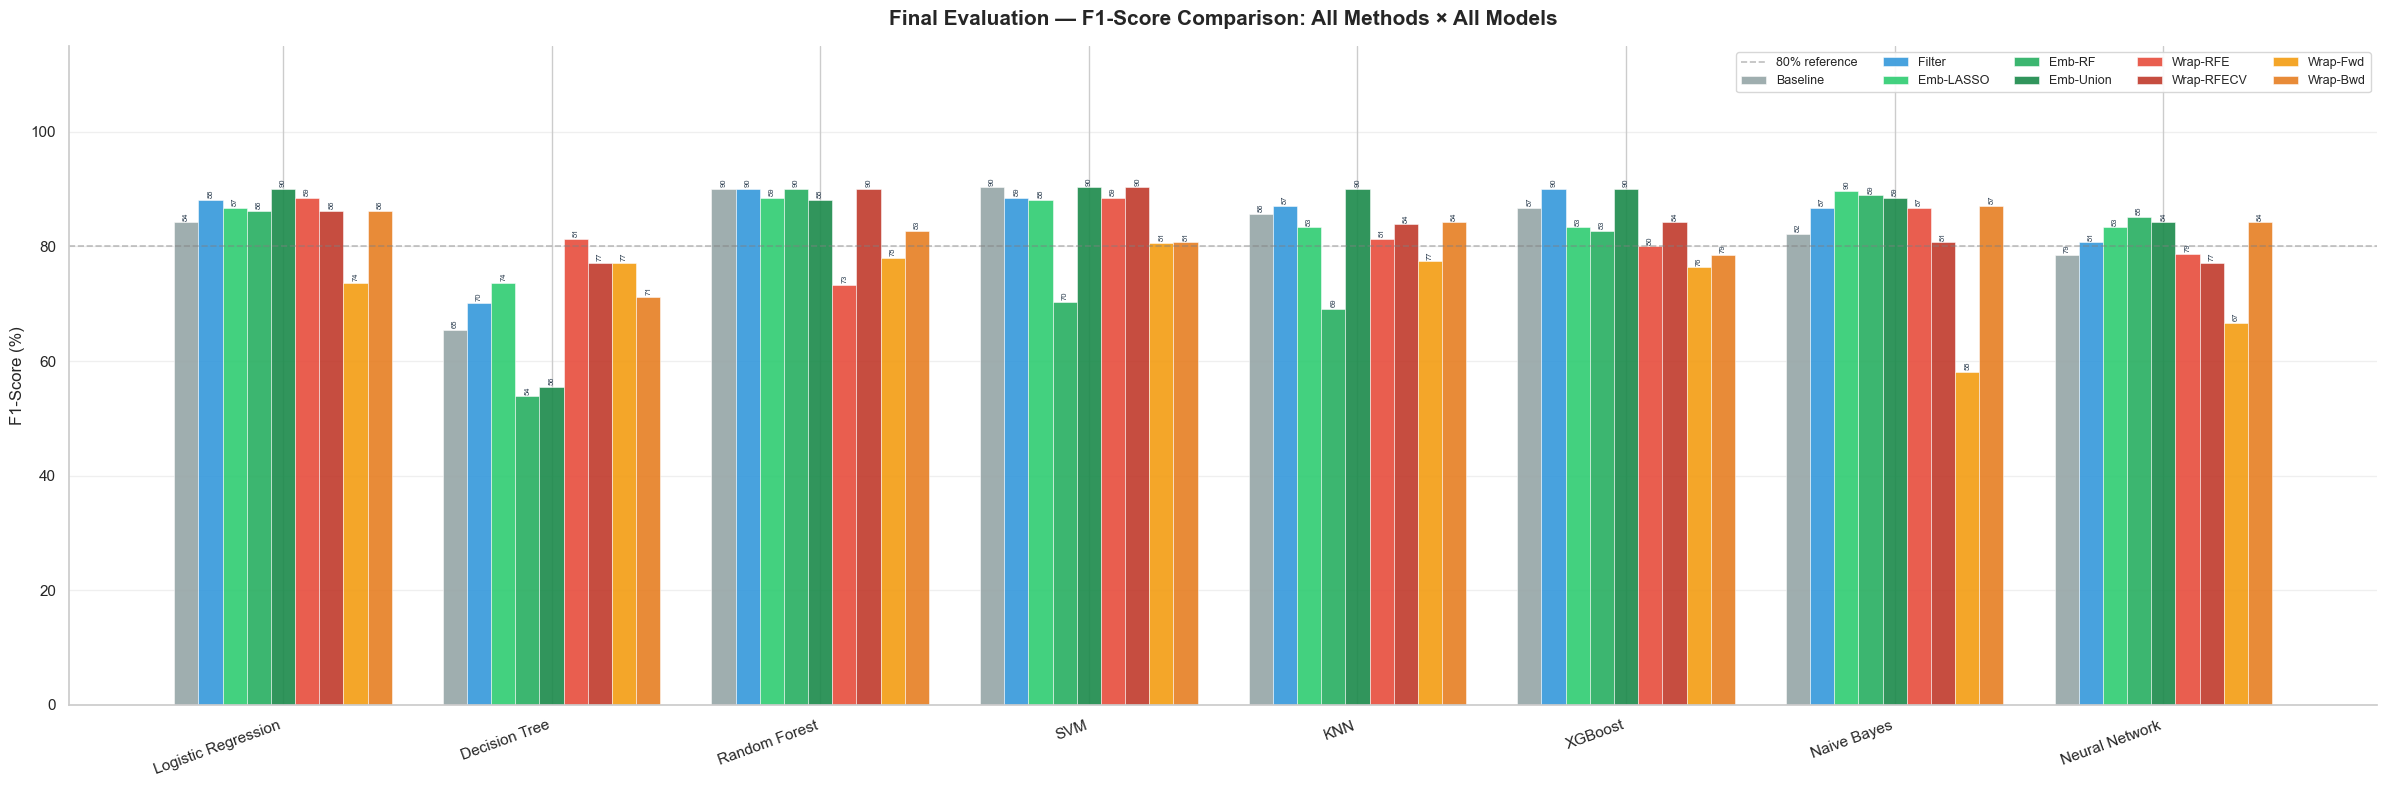

✅ Grouped bar chart saved!


In [7]:
method_colors = {
    'Baseline'   : '#95a5a6',
    'Filter'     : '#3498db',
    'Emb-LASSO'  : '#2ecc71',
    'Emb-RF'     : '#27ae60',
    'Emb-Union'  : '#1a8a4a',
    'Wrap-RFE'   : '#e74c3c',
    'Wrap-RFECV' : '#c0392b',
    'Wrap-Fwd'   : '#f39c12',
    'Wrap-Bwd'   : '#e67e22',
}

x         = np.arange(len(MODEL_NAMES))
n_methods = len(method_cols)
bar_width = 0.09

fig, ax = plt.subplots(figsize=(24, 8))

for i, method in enumerate(method_cols):
    vals    = master_df[method].values
    offsets = x + (i - n_methods / 2) * bar_width + bar_width / 2
    bars    = ax.bar(offsets, vals, bar_width,
                     label=method, color=method_colors[method],
                     edgecolor='white', linewidth=0.4, alpha=0.90)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f'{val:.0f}', ha='center', va='bottom',
                fontsize=5.5, rotation=90, color='#2c3e50')

ax.set_xticks(x)
ax.set_xticklabels(MODEL_NAMES, rotation=20, ha='right', fontsize=11)
ax.set_ylabel('F1-Score (%)', fontsize=12)
ax.set_ylim(0, 115)
ax.set_title('Final Evaluation — F1-Score Comparison: All Methods × All Models',
             fontsize=15, fontweight='bold', pad=15)
ax.axhline(80, color='gray', linestyle='--', linewidth=1.2, alpha=0.5, label='80% reference')
ax.legend(fontsize=9, loc='upper right', ncol=5,
          framealpha=0.9, edgecolor='lightgray')
ax.grid(axis='y', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('png/final_grouped_barchart.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grouped bar chart saved!')

## Cell 7 — Performance Heatmaps: Side-by-Side


Three heatmaps side by side showing Accuracy, Recall, F1, AUC
for:  Baseline | Best Embedded | Best Wrapper
This makes it very easy to see where the biggest improvements are.

Best Embedded subset : Emb-Union  (avg F1 = 84.59%)
Best Wrapper  subset : Wrap-RFECV  (avg F1 = 83.71%)
Computing full metrics for heatmaps...


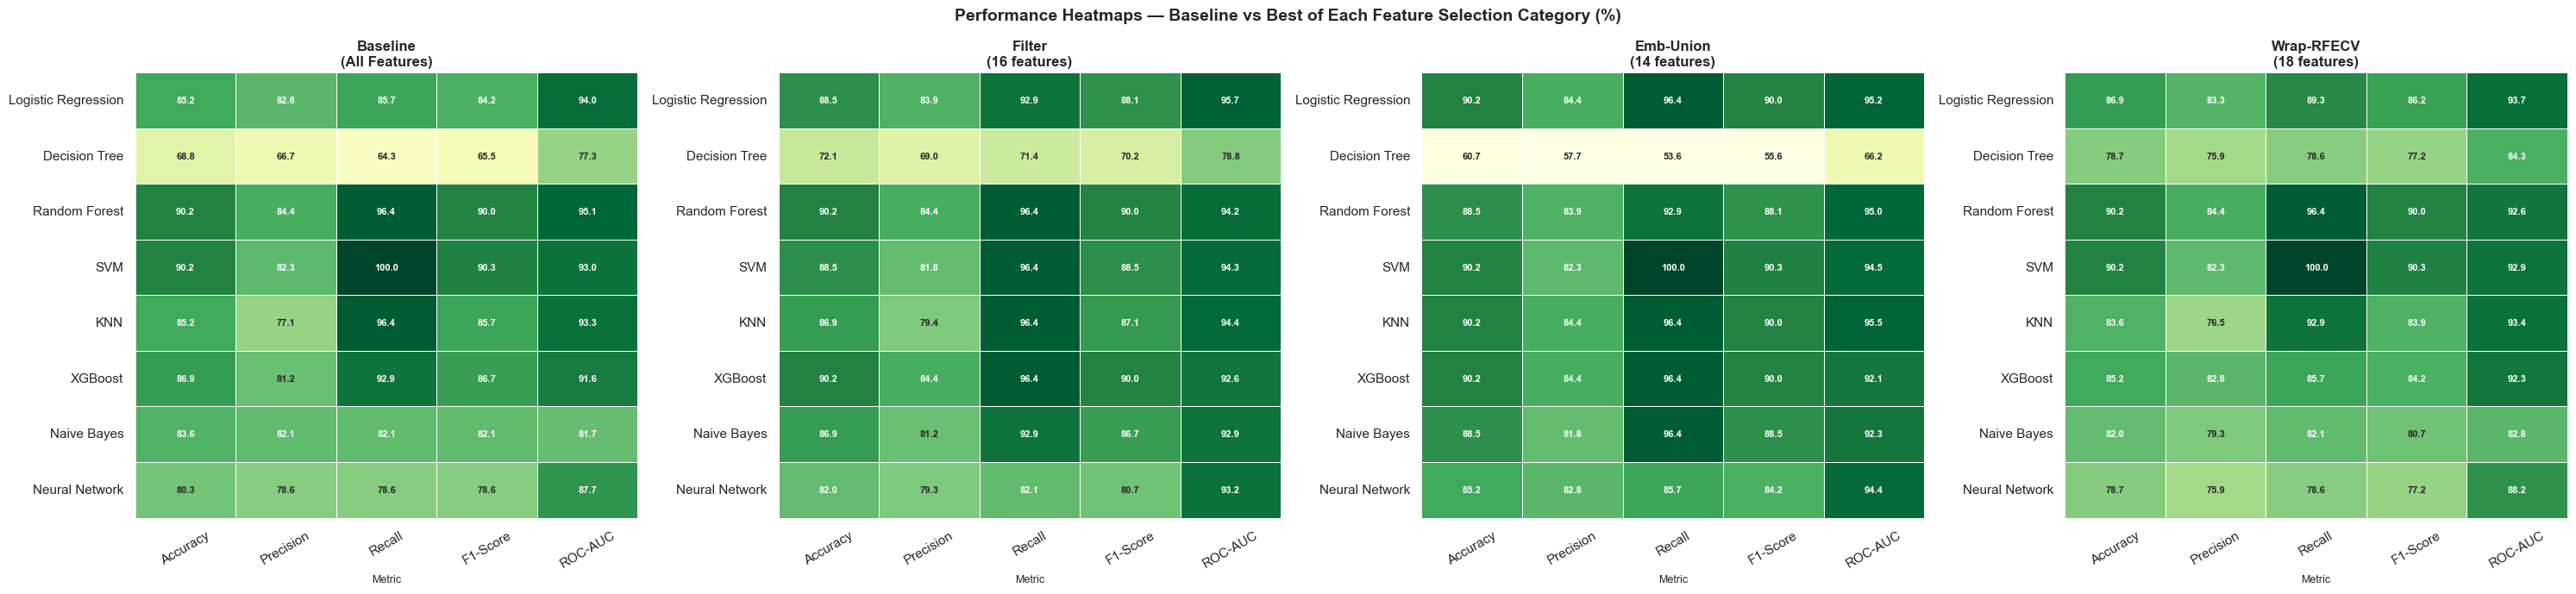

✅ Heatmaps saved!


In [8]:
def full_eval(X_tr, X_te, names=None):
    """Train all 8 models and return full metrics dict."""
    if names is None:
        names = get_models().keys()
    res = {}
    for name, model in get_models().items():
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]
        res[name] = {
            'Accuracy' : round(accuracy_score(y_test, y_pred) * 100, 2),
            'Precision': round(precision_score(y_test, y_pred, zero_division=0) * 100, 2),
            'Recall'   : round(recall_score(y_test, y_pred, zero_division=0) * 100, 2),
            'F1-Score' : round(f1_score(y_test, y_pred, zero_division=0) * 100, 2),
            'ROC-AUC'  : round(roc_auc_score(y_test, y_prob) * 100, 2),
        }
    return res

# Find best embedded subset by avg F1
avg_emb = {
    'Emb-LASSO' : np.mean([results_lasso[n]['F1-Score'] for n in MODEL_NAMES]),
    'Emb-RF'    : np.mean([results_rf[n]['F1-Score']    for n in MODEL_NAMES]),
    'Emb-Union' : np.mean([results_union[n]['F1-Score'] for n in MODEL_NAMES]),
}
best_emb_name = max(avg_emb, key=avg_emb.get)
best_emb_feat = {'Emb-LASSO': embedded_lasso_features,
                 'Emb-RF':    embedded_rf_features,
                 'Emb-Union': embedded_union_features}[best_emb_name]

# Find best wrapper subset by avg F1
avg_wrap = {
    'Wrap-RFE'   : np.mean(list(w_rfe.values())),
    'Wrap-RFECV' : np.mean(list(w_rcv.values())),
    'Wrap-Fwd'   : np.mean(list(w_fwd.values())),
    'Wrap-Bwd'   : np.mean(list(w_bwd.values())),
}
best_wrap_name = max(avg_wrap, key=avg_wrap.get)
best_wrap_feat = {'Wrap-RFE'   : rfe_features_for_eval,
                  'Wrap-RFECV' : wrapper_rfecv_features,
                  'Wrap-Fwd'   : wrapper_forward_features,
                  'Wrap-Bwd'   : wrapper_backward_features}[best_wrap_name]

print(f'Best Embedded subset : {best_emb_name}  (avg F1 = {avg_emb[best_emb_name]:.2f}%)')
print(f'Best Wrapper  subset : {best_wrap_name}  (avg F1 = {avg_wrap[best_wrap_name]:.2f}%)')

# Compute full metrics for best embedded, best wrapper
best_emb_scaled = X_train_scaled[best_emb_feat]
best_emb_te     = X_test_scaled[best_emb_feat]
best_wrap_tr    = X_train_scaled[best_wrap_feat]
best_wrap_te    = X_test_scaled[best_wrap_feat]

print('Computing full metrics for heatmaps...')
full_best_emb  = full_eval(best_emb_scaled, best_emb_te)
full_best_wrap = full_eval(best_wrap_tr, best_wrap_te)
full_filter    = filter_full_results

metrics_to_show = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

def to_df(results_dict, model_names):
    df = pd.DataFrame({n: results_dict[n] for n in model_names}).T
    return df[metrics_to_show]

base_hm   = to_df(baseline_results,  MODEL_NAMES)
filt_hm   = to_df(full_filter,       MODEL_NAMES)
emb_hm    = to_df(full_best_emb,     MODEL_NAMES)
wrap_hm   = to_df(full_best_wrap,    MODEL_NAMES)

fig, axes = plt.subplots(1, 4, figsize=(30, 7))
titles    = ['Baseline\n(All Features)',
             f'Filter\n({len(filter_selected_features)} features)',
             f'{best_emb_name}\n({len(best_emb_feat)} features)',
             f'{best_wrap_name}\n({len(best_wrap_feat)} features)']
dfs       = [base_hm, filt_hm, emb_hm, wrap_hm]

for ax, df, title in zip(axes, dfs, titles):
    sns.heatmap(
        df, ax=ax, annot=True, fmt='.1f', cmap='YlGn',
        vmin=60, vmax=100, linewidths=0.4, linecolor='white',
        annot_kws={'size': 8, 'weight': 'bold'}, cbar=False
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Metric', fontsize=9)
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Performance Heatmaps — Baseline vs Best of Each Feature Selection Category (%)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('png/final_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmaps saved!')

## Cell 8 — Radar Chart: Best Embedded vs Best Wrapper vs Baseline


A radar (spider) chart shows 5 metrics at once for a given model.
We pick the BEST model overall (highest F1 across all methods)
and compare its performance profile under:
  - Baseline
  - Best Embedded method
  - Best Wrapper method
  - Filter method

This makes it visually clear how each method shifts the balance
between accuracy, precision, recall, F1, and AUC.

Best overall model: SVM


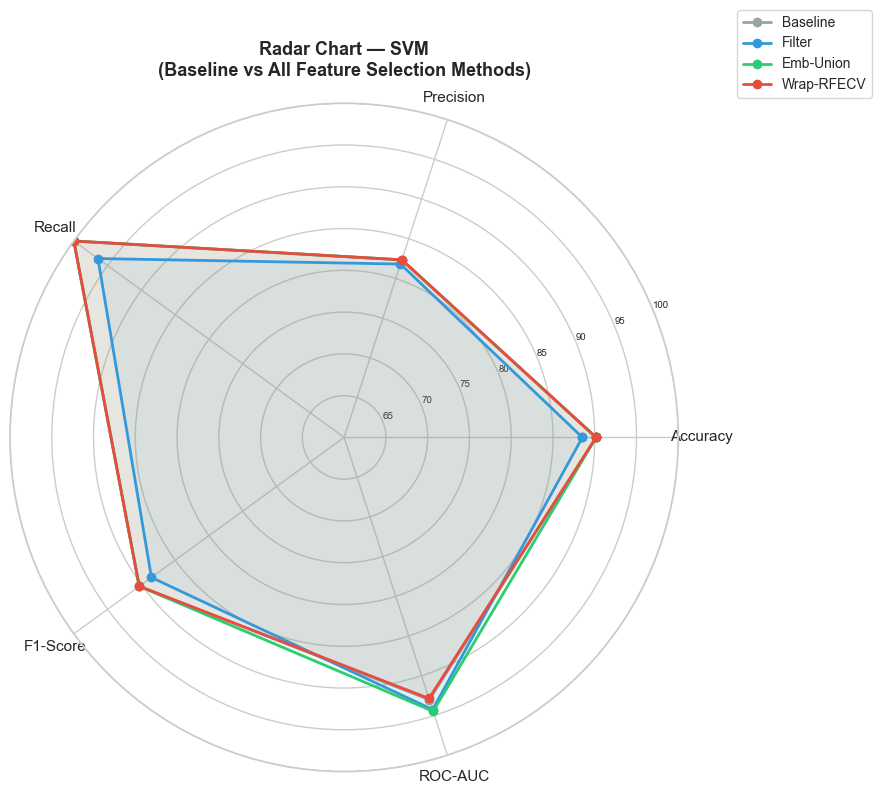

✅ Radar chart saved!


In [9]:
# Find the single best model name (highest max F1 across methods)
best_overall_model = master_df.max(axis=1).idxmax()
print(f'Best overall model: {best_overall_model}')

metrics_radar = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

def radar_vals(results_dict, model_name, metrics):
    return [results_dict[model_name][m] for m in metrics]

base_vals  = radar_vals(baseline_results, best_overall_model, metrics_radar)
filt_vals  = radar_vals(full_filter,      best_overall_model, metrics_radar)
emb_vals   = radar_vals(full_best_emb,    best_overall_model, metrics_radar)
wrap_vals  = radar_vals(full_best_wrap,   best_overall_model, metrics_radar)

N      = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

def close(vals):
    return vals + vals[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

series_list = [
    (base_vals,  'Baseline',        '#95a5a6'),
    (filt_vals,  'Filter',          '#3498db'),
    (emb_vals,   best_emb_name,     '#2ecc71'),
    (wrap_vals,  best_wrap_name,    '#e74c3c'),
]

for vals, label, color in series_list:
    ax.plot(angles, close(vals), 'o-', linewidth=2, label=label, color=color)
    ax.fill(angles, close(vals), alpha=0.08, color=color)

ax.set_thetagrids(np.degrees(angles[:-1]), metrics_radar, fontsize=11)
ax.set_ylim(60, 100)
ax.set_yticks([65, 70, 75, 80, 85, 90, 95, 100])
ax.set_yticklabels(['65', '70', '75', '80', '85', '90', '95', '100'], fontsize=7)
ax.set_title(f'Radar Chart — {best_overall_model}\n(Baseline vs All Feature Selection Methods)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=10)

plt.tight_layout()
plt.savefig('png/final_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Radar chart saved!')

## Cell 9 — ROC Curves: Best Model From Each Method


We retrain the best model (identified in Cell 8) under four conditions
and plot their ROC curves on a single graph.

The ROC curve shows how well each method lets the model separate
sick from healthy patients across all decision thresholds.
AUC = Area Under the Curve — closer to 1.0 is better.

Plotting ROC curves for best model: SVM


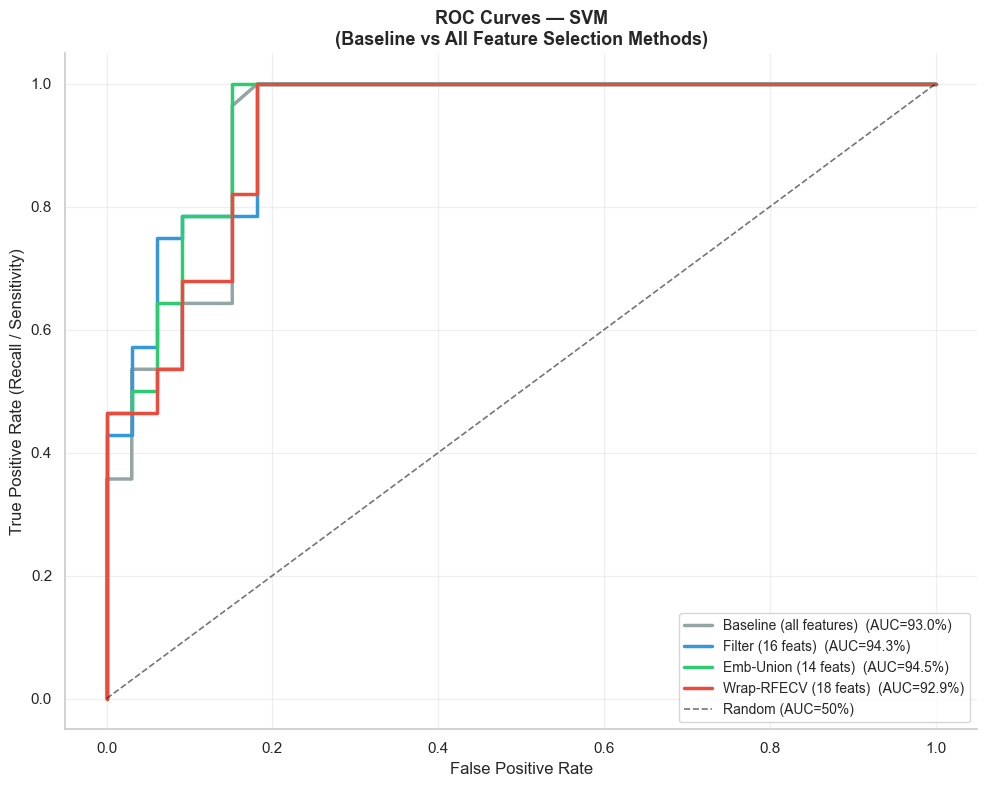

✅ ROC curves saved!


In [10]:
print(f'Plotting ROC curves for best model: {best_overall_model}')

best_model_class = get_models()[best_overall_model]

def roc_for_model(model_class, X_tr, X_te, label, color, ax):
    model_class.fit(X_tr, y_train)
    y_prob = model_class.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=2.5, label=f'{label}  (AUC={auc_val*100:.1f}%)', color=color)
    return auc_val

fig, ax = plt.subplots(figsize=(10, 8))

roc_for_model(get_models()[best_overall_model],
              X_train_scaled, X_test_scaled,
              'Baseline (all features)', '#95a5a6', ax)

roc_for_model(get_models()[best_overall_model],
              X_train_filter, X_test_filter,
              f'Filter ({len(filter_selected_features)} feats)', '#3498db', ax)

roc_for_model(get_models()[best_overall_model],
              X_train_scaled[best_emb_feat], X_test_scaled[best_emb_feat],
              f'{best_emb_name} ({len(best_emb_feat)} feats)', '#2ecc71', ax)

roc_for_model(get_models()[best_overall_model],
              X_train_scaled[best_wrap_feat], X_test_scaled[best_wrap_feat],
              f'{best_wrap_name} ({len(best_wrap_feat)} feats)', '#e74c3c', ax)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.6, label='Random (AUC=50%)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=12)
ax.set_title(f'ROC Curves — {best_overall_model}\n(Baseline vs All Feature Selection Methods)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('png/final_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ ROC curves saved!')

## Cell 10 — Confusion Matrices: Best Model Under Each Method


Confusion matrix shows the 4 prediction types:
  TP  True Positive  = correctly predicted sick
  TN  True Negative  = correctly predicted healthy
  FP  False Positive = healthy predicted as sick (false alarm)
  FN  False Negative = sick predicted as healthy  ← MOST DANGEROUS

We show 4 matrices (Baseline, Filter, Best Embedded, Best Wrapper)
for the best overall model to see how FN count changes.

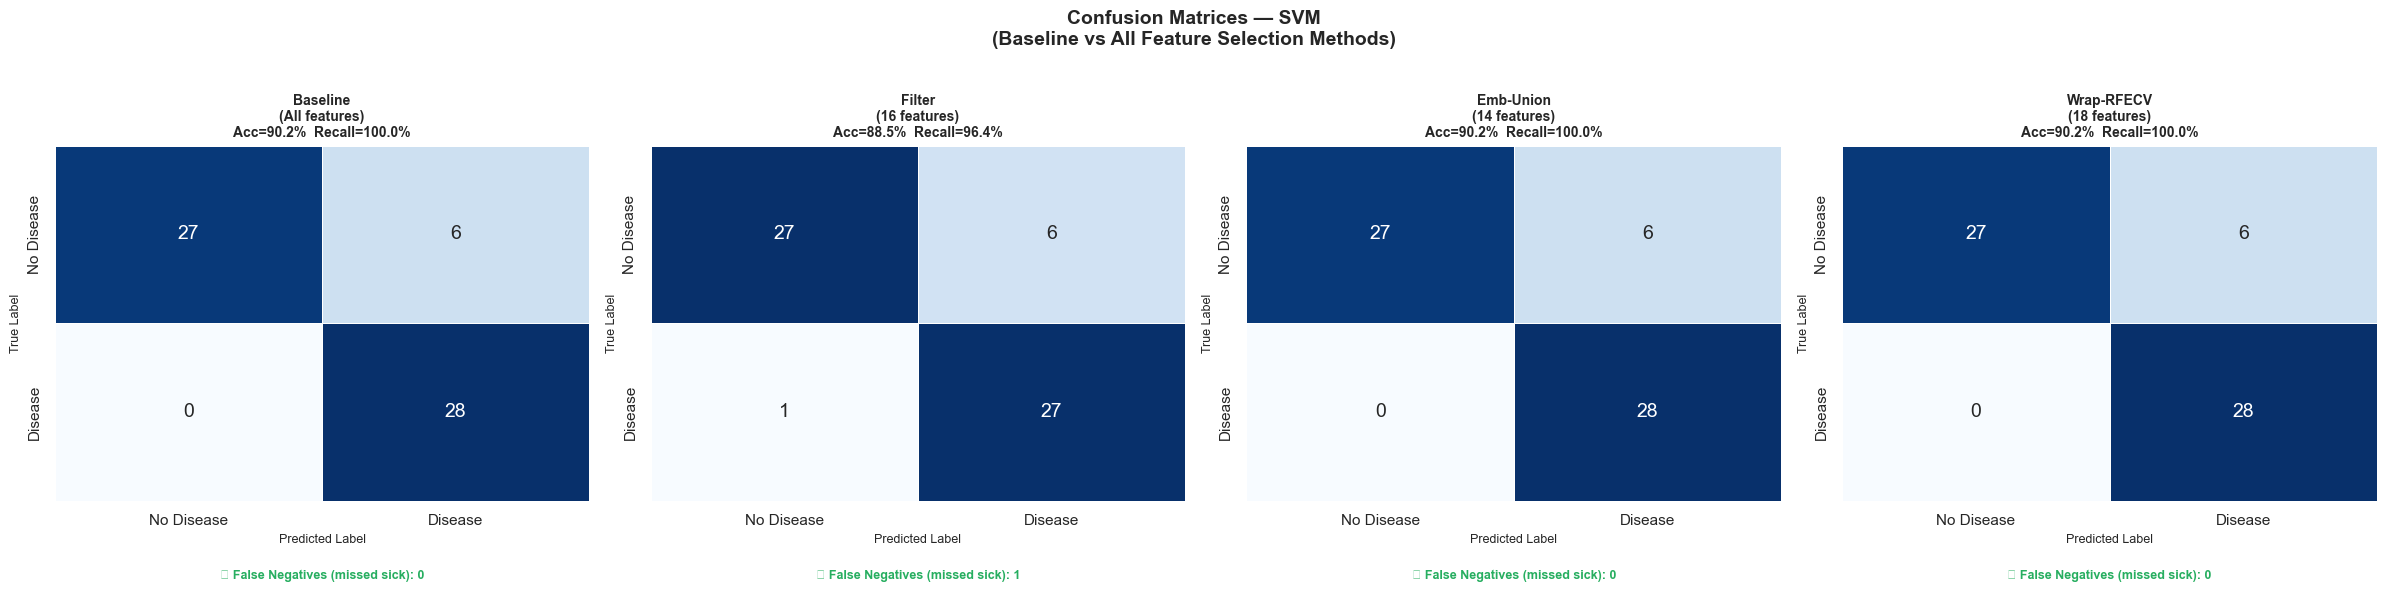

✅ Confusion matrices saved!


In [11]:
configs = [
    ('Baseline\n(All features)',          X_train_scaled,                   X_test_scaled),
    (f'Filter\n({len(filter_selected_features)} features)', X_train_filter, X_test_filter),
    (f'{best_emb_name}\n({len(best_emb_feat)} features)',
     X_train_scaled[best_emb_feat], X_test_scaled[best_emb_feat]),
    (f'{best_wrap_name}\n({len(best_wrap_feat)} features)',
     X_train_scaled[best_wrap_feat], X_test_scaled[best_wrap_feat]),
]

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle(f'Confusion Matrices — {best_overall_model}\n(Baseline vs All Feature Selection Methods)',
             fontsize=14, fontweight='bold', y=1.02)

for ax, (title, X_tr, X_te) in zip(axes, configs):
    model = get_models()[best_overall_model]
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    acc = accuracy_score(y_test, y_pred) * 100
    rec = recall_score(y_test, y_pred, zero_division=0) * 100

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                linewidths=0.5, cbar=False, annot_kws={'size': 14})
    ax.set_title(f'{title}\nAcc={acc:.1f}%  Recall={rec:.1f}%',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=9)
    ax.set_ylabel('True Label', fontsize=9)
    ax.text(0.5, -0.22,
            f'❗ False Negatives (missed sick): {fn}',
            transform=ax.transAxes, ha='center', fontsize=9,
            color='#c0392b' if fn > 3 else '#27ae60', fontweight='bold')

plt.tight_layout()
plt.savefig('png/final_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrices saved!')

## Cell 11 — Recall Focus: Who Misses Fewest Sick Patients?


In medical diagnosis, RECALL is the most critical metric.
Missing a sick patient (False Negative) can be life-threatening.
This cell ranks all methods by their average Recall across all models.

We also visualise Recall per model per method so we can see
which combinations are most reliable at catching sick patients.

Computing per-model Recall for all wrapper methods...


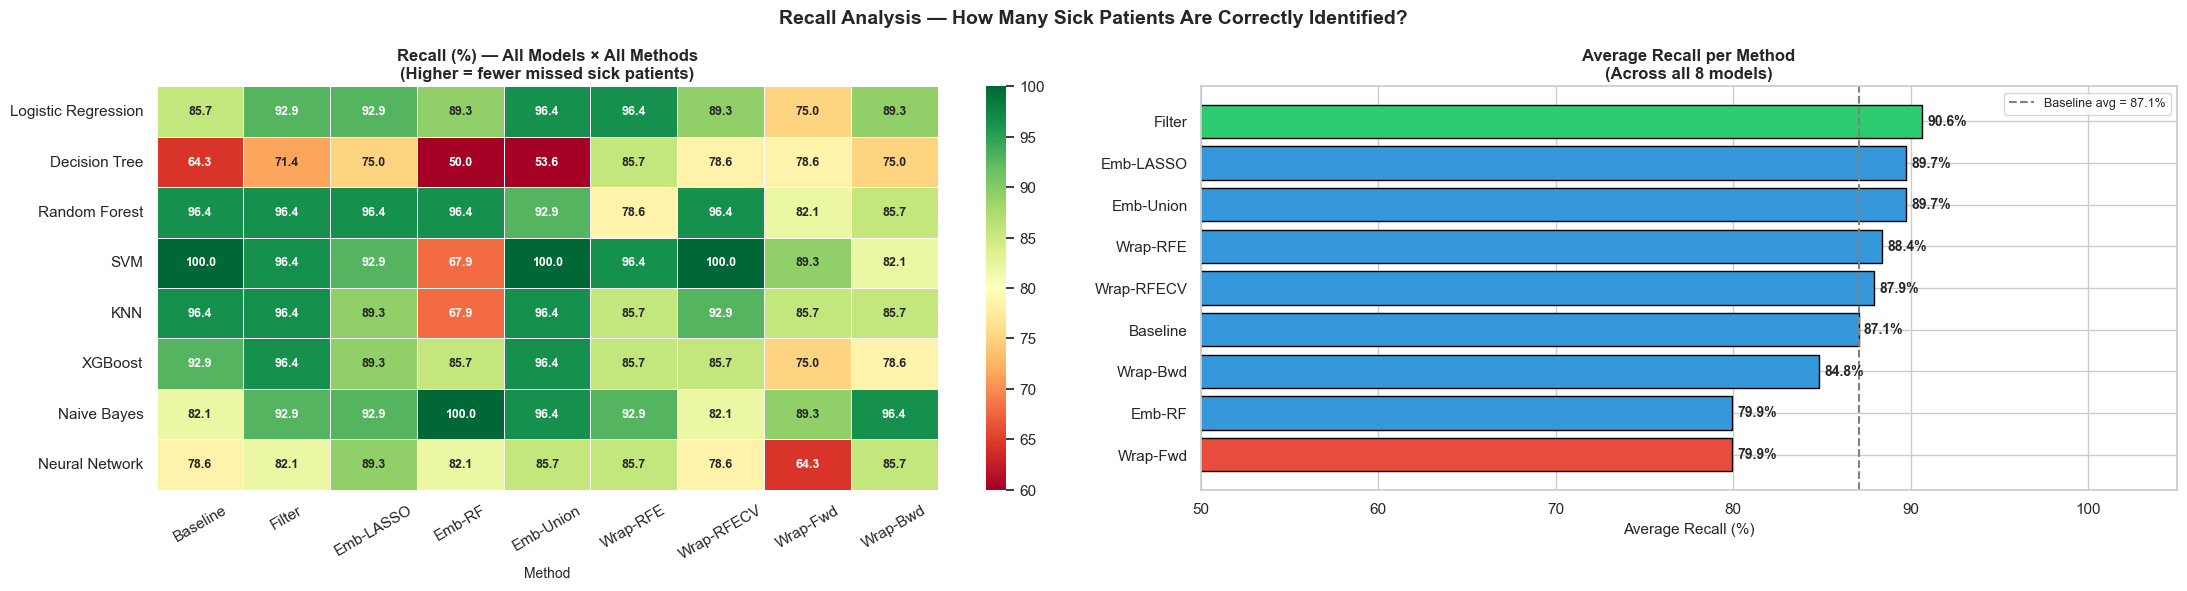

✅ Recall analysis saved!


In [12]:
recall_data = {}

for name in MODEL_NAMES:
    recall_data[name] = {
        'Baseline'  : baseline_results[name]['Recall'],
        'Filter'    : full_filter[name]['Recall'],
        'Emb-LASSO' : results_lasso[name]['Recall'],
        'Emb-RF'    : results_rf[name]['Recall'],
        'Emb-Union' : results_union[name]['Recall'],
    }

# Add wrapper recalls (already computed per model above)
def get_model_recalls(features, X_tr_full, X_te_full):
    res = {}
    for name, model in get_models().items():
        X_tr = X_tr_full[features]
        X_te = X_te_full[features]
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)
        res[name] = round(recall_score(y_test, y_pred, zero_division=0) * 100, 2)
    return res

print('Computing per-model Recall for all wrapper methods...')
rec_rfe  = get_model_recalls(rfe_features_for_eval,   X_train_scaled, X_test_scaled)
rec_rcv  = get_model_recalls(wrapper_rfecv_features,   X_train_scaled, X_test_scaled)
rec_fwd  = get_model_recalls(wrapper_forward_features, X_train_scaled, X_test_scaled)
rec_bwd  = get_model_recalls(wrapper_backward_features,X_train_scaled, X_test_scaled)

for name in MODEL_NAMES:
    recall_data[name]['Wrap-RFE']   = rec_rfe[name]
    recall_data[name]['Wrap-RFECV'] = rec_rcv[name]
    recall_data[name]['Wrap-Fwd']   = rec_fwd[name]
    recall_data[name]['Wrap-Bwd']   = rec_bwd[name]

recall_df = pd.DataFrame(recall_data).T   # models as rows, methods as columns
recall_df = recall_df[method_cols]

# --- Plot: Recall heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(22, 6))

sns.heatmap(recall_df, ax=axes[0], annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=60, vmax=100, linewidths=0.4, linecolor='white',
            annot_kws={'size': 9, 'weight': 'bold'})
axes[0].set_title('Recall (%) — All Models × All Methods\n(Higher = fewer missed sick patients)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Method', fontsize=10)
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# Average recall per method (bar chart)
avg_recall = recall_df.mean().sort_values(ascending=True)
colors_rec = ['#2ecc71' if v == avg_recall.max()
              else '#e74c3c' if v == avg_recall.min()
              else '#3498db' for v in avg_recall.values]
bars = axes[1].barh(avg_recall.index, avg_recall.values,
                    color=colors_rec, edgecolor='black')
for bar, val in zip(bars, avg_recall.values):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontweight='bold', fontsize=10)
axes[1].axvline(avg_recall['Baseline'], color='gray', linestyle='--',
                linewidth=1.5, label=f'Baseline avg = {avg_recall["Baseline"]:.1f}%')
axes[1].set_xlabel('Average Recall (%)', fontsize=11)
axes[1].set_title('Average Recall per Method\n(Across all 8 models)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlim(50, 105)
axes[1].legend(fontsize=9)

plt.suptitle('Recall Analysis — How Many Sick Patients Are Correctly Identified?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('png/final_recall_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Recall analysis saved!')

## Cell 12 — Feature Importance Summary Across Methods


Which features were selected by multiple methods?
A feature selected by all three categories (Filter, Embedded, Wrapper)
is the most robustly important — different algorithmic approaches
all agreed it matters.

We visualise:
1. A binary heatmap: was each feature selected by each method?
2. A vote bar chart: how many methods selected each feature?

Feature Selection Votes Across All Methods:
  ⭐ slope_2.0           : 6/7 votes  ██████
  ⭐ thalach             : 6/7 votes  ██████
  ⭐ oldpeak             : 6/7 votes  ██████
  ⭐ cp_4.0              : 6/7 votes  ██████
  ⭐ sex                 : 6/7 votes  ██████
  ⭐ thal_7              : 6/7 votes  ██████
  ⭐ ca_3                : 5/7 votes  █████
  ⭐ trestbps            : 5/7 votes  █████
  ⭐ chol                : 5/7 votes  █████
  ⭐ exang               : 5/7 votes  █████
  ⭐ ca_1                : 5/7 votes  █████
  ⭐ cp_3.0              : 5/7 votes  █████
  ✅ ca_2                : 4/7 votes  ████
  ✅ age                 : 4/7 votes  ████
     restecg_2.0         : 2/7 votes  ██
     cp_2.0              : 2/7 votes  ██
     restecg_1.0         : 2/7 votes  ██
     slope_3.0           : 1/7 votes  █
     thal_4              : 1/7 votes  █
     fbs                 : 1/7 votes  █
     thal_5              : 0/7 votes  
     thal_6              : 0/7 votes  


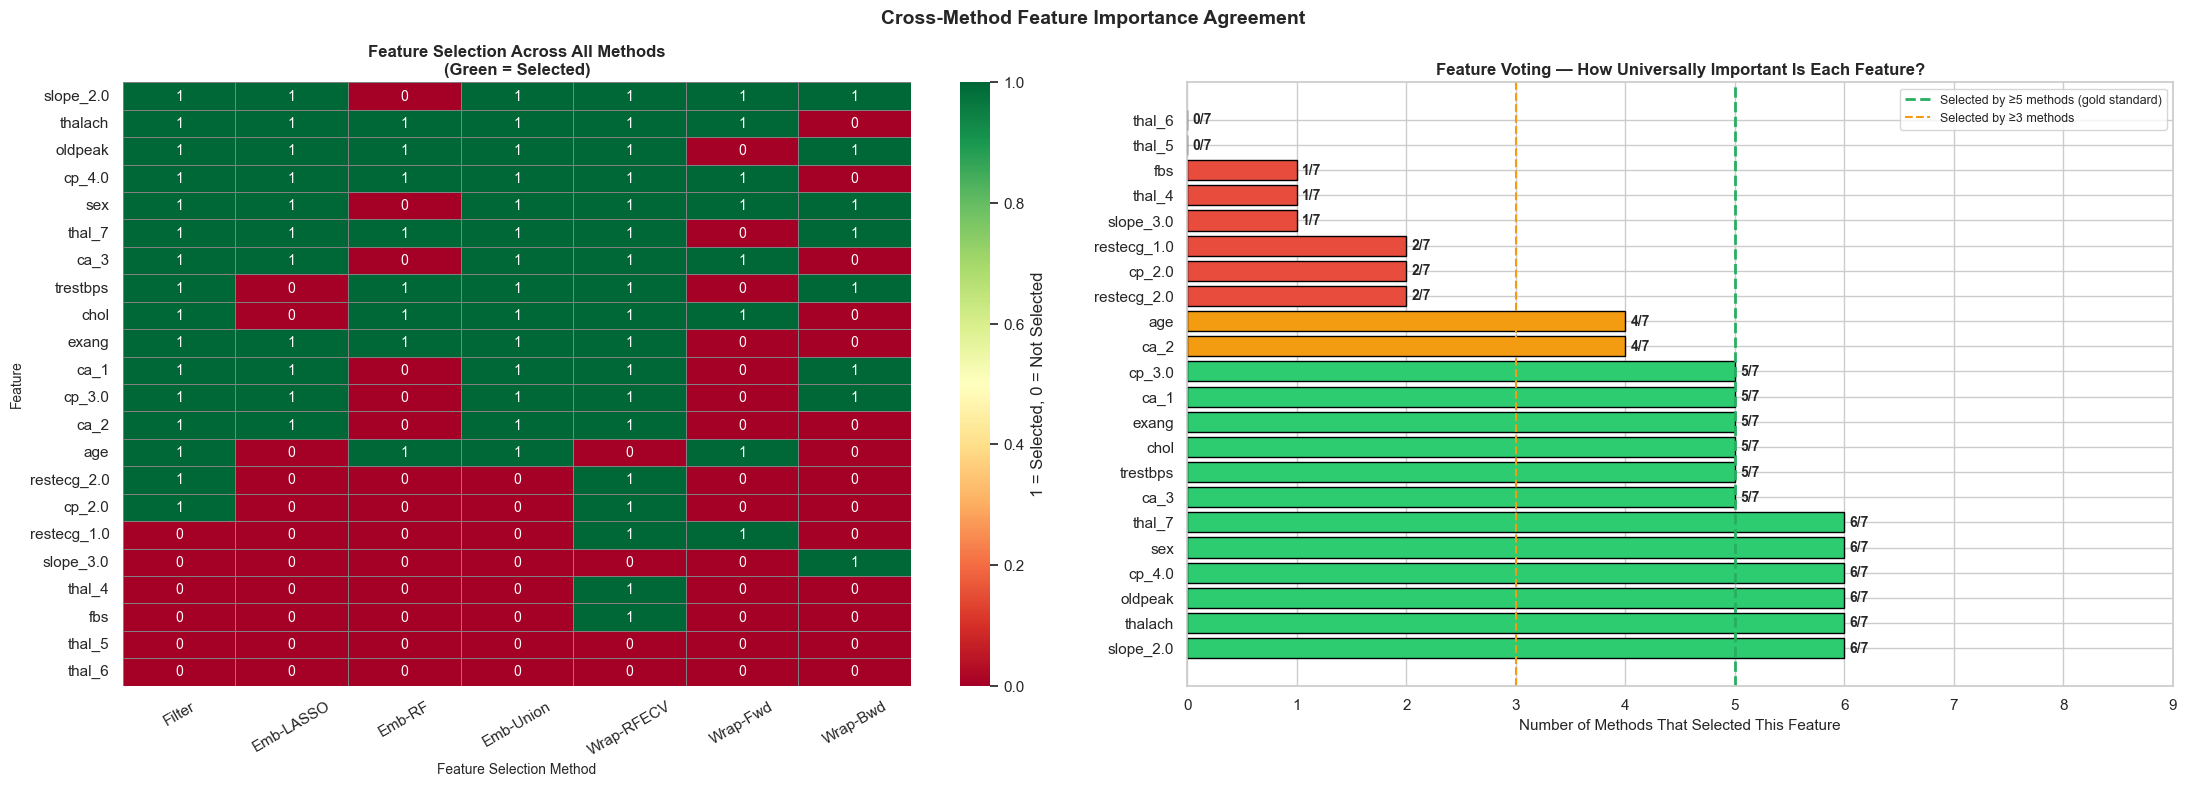

✅ Feature importance chart saved!

⭐ Gold-standard features (selected by ≥5/7 methods): 12
   → ['slope_2.0', 'thalach', 'oldpeak', 'cp_4.0', 'sex', 'thal_7', 'ca_3', 'trestbps', 'chol', 'exang', 'ca_1', 'cp_3.0']


In [13]:
# Build a binary selection matrix: rows=features, columns=methods
all_method_features = {
    'Filter'      : set(filter_selected_features),
    'Emb-LASSO'   : set(embedded_lasso_features),
    'Emb-RF'      : set(embedded_rf_features),
    'Emb-Union'   : set(embedded_union_features),
    'Wrap-RFECV'  : set(wrapper_rfecv_features),
    'Wrap-Fwd'    : set(wrapper_forward_features),
    'Wrap-Bwd'    : set(wrapper_backward_features),
}

selection_matrix = pd.DataFrame(
    {method: [1 if f in feats else 0 for f in feature_names]
     for method, feats in all_method_features.items()},
    index=feature_names
)
selection_matrix['Total Votes'] = selection_matrix.sum(axis=1)
selection_matrix = selection_matrix.sort_values('Total Votes', ascending=False)

print('Feature Selection Votes Across All Methods:')
print('=' * 60)
for feat, row in selection_matrix.iterrows():
    votes = int(row['Total Votes'])
    bar   = '█' * votes
    stars = '⭐' if votes >= 5 else ('✅' if votes >= 3 else '  ')
    print(f'  {stars} {feat:<20}: {votes}/7 votes  {bar}')

# --- Visualisations ---
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Heatmap
sns.heatmap(
    selection_matrix.drop(columns='Total Votes'),
    ax=axes[0], cmap='RdYlGn', linewidths=0.5,
    linecolor='gray', annot=True, fmt='d',
    cbar_kws={'label': '1 = Selected, 0 = Not Selected'},
    annot_kws={'size': 10}
)
axes[0].set_title('Feature Selection Across All Methods\n(Green = Selected)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Feature Selection Method', fontsize=10)
axes[0].set_ylabel('Feature', fontsize=10)
axes[0].tick_params(axis='x', rotation=30)

# Vote bar chart
votes    = selection_matrix['Total Votes']
bar_cols = ['#2ecc71' if v >= 5 else '#f39c12' if v >= 3 else '#e74c3c'
            for v in votes.values]
bars = axes[1].barh(votes.index, votes.values, color=bar_cols, edgecolor='black')
axes[1].axvline(5, color='#27ae60', linestyle='--', linewidth=2,
                label='Selected by ≥5 methods (gold standard)')
axes[1].axvline(3, color='#f39c12', linestyle='--', linewidth=1.5,
                label='Selected by ≥3 methods')
for bar, val in zip(bars, votes.values):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
                f'{int(val)}/7', va='center', fontweight='bold', fontsize=10)
axes[1].set_xlabel('Number of Methods That Selected This Feature', fontsize=11)
axes[1].set_title('Feature Voting — How Universally Important Is Each Feature?',
                  fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 9)
axes[1].legend(fontsize=9)

plt.suptitle('Cross-Method Feature Importance Agreement', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('png/final_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature importance chart saved!')

# Print the most universally selected features
gold_features = selection_matrix[selection_matrix['Total Votes'] >= 5].index.tolist()
print(f'\n⭐ Gold-standard features (selected by ≥5/7 methods): {len(gold_features)}')
print(f'   → {gold_features}')

## Cell 13 — Final Ranking Table + Winner Declaration


This cell produces the final verdict:
- Overall best method (highest avg F1 across all models)
- Overall best model (highest F1 in any configuration)
- Best model-method combination
- Medical verdict: which combo catches the most sick patients?

             FINAL RANKING — FEATURE SELECTION METHODS

📊 Methods Ranked by Average F1-Score (All 8 models):
--------------------------------------------------
  🥇 Filter        : 85.16% (+2.3%)
  🥈 Emb-Union     : 84.59% (+1.7%)
  🥉 Emb-LASSO     : 84.58% (+1.7%)
   4. Wrap-RFECV    : 83.71% (+0.8%)
   5. Baseline      : 82.88% (0.0%)
   6. Wrap-RFE      : 82.31% (-0.6%)
   7. Wrap-Bwd      : 81.87% (-1.0%)
   8. Emb-RF        : 78.30% (-4.6%)
   9. Wrap-Fwd      : 73.51% (-9.4%)

🏆 Top 10 Best Model-Method Combinations (by F1-Score):
-------------------------------------------------------
   1. SVM                    + Baseline      : 90.32%
   2. SVM                    + Emb-Union     : 90.32%
   3. SVM                    + Wrap-RFECV    : 90.32%
   4. Logistic Regression    + Emb-Union     : 90.00%
   5. Random Forest          + Baseline      : 90.00%
   6. Random Forest          + Filter        : 90.00%
   7. Random Forest          + Emb-RF        : 90.00%
   8. Random Forest     

,Method,Avg F1 (%),Δ Baseline,Avg Recall (%)
Rank,,,,
1,Filter,85.16%,+2.28%,90.63%
2,Emb-Union,84.59%,+1.71%,89.73%
3,Emb-LASSO,84.58%,+1.70%,89.74%
4,Wrap-RFECV,83.71%,+0.83%,87.95%
5,Baseline,82.88%,+0.00%,87.05%
6,Wrap-RFE,82.31%,-0.57%,88.39%
7,Wrap-Bwd,81.87%,-1.01%,84.82%
8,Emb-RF,78.30%,-4.58%,79.91%
9,Wrap-Fwd,73.51%,-9.37%,79.91%


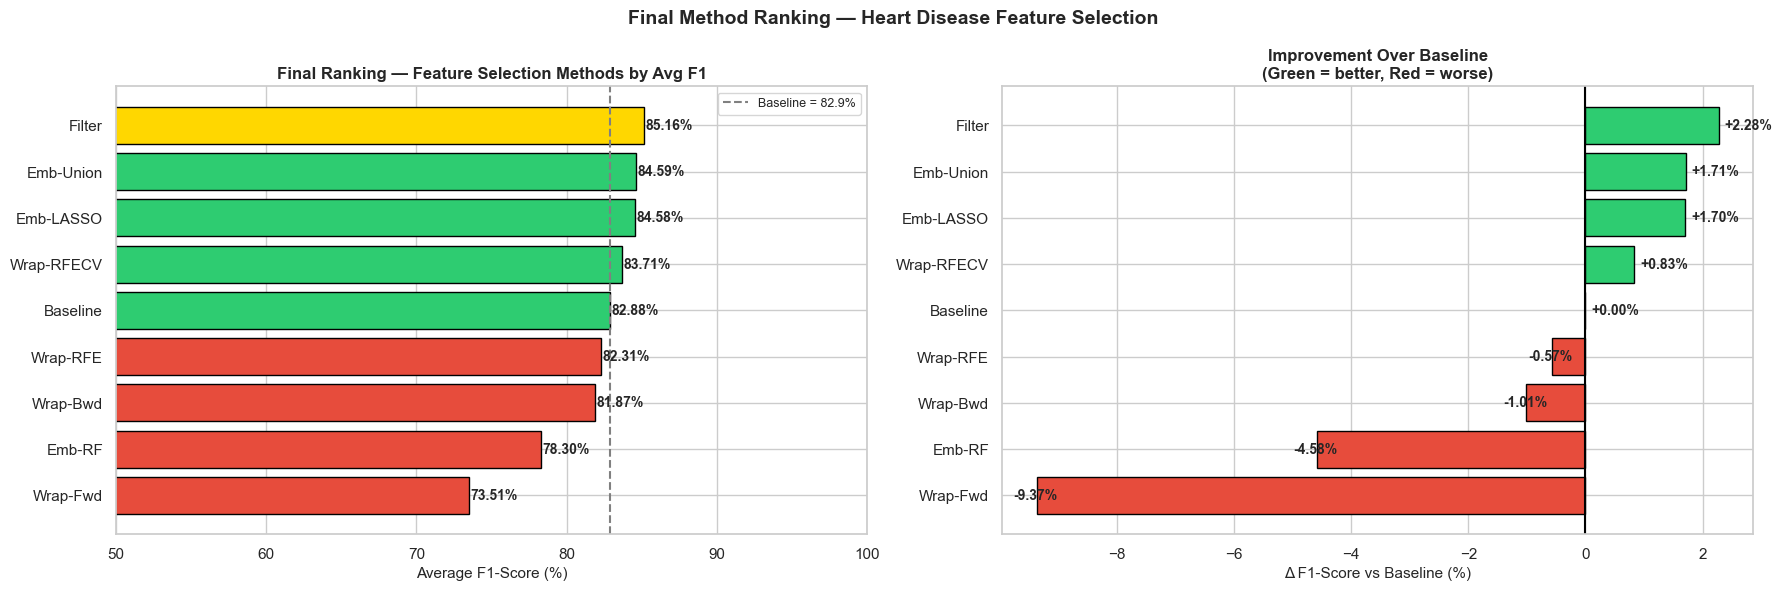

✅ Final ranking chart saved!


In [14]:
print('=' * 70)
print('             FINAL RANKING — FEATURE SELECTION METHODS')
print('=' * 70)

# Average F1 per method
avg_f1_methods = master_df.mean().sort_values(ascending=False).round(2)

print('\n📊 Methods Ranked by Average F1-Score (All 8 models):')
print('-' * 50)
for rank, (method, val) in enumerate(avg_f1_methods.items(), 1):
    medal = ['🥇', '🥈', '🥉'][rank - 1] if rank <= 3 else f' {rank}.'
    delta = val - avg_f1_methods['Baseline']
    trend = f' (+{delta:.1f}%)' if delta > 0 else f' ({delta:.1f}%)'
    print(f'  {medal} {method:<14}: {val:.2f}%{trend}')

# Best model-method combo
flat_scores = []
for model in MODEL_NAMES:
    for method in method_cols:
        flat_scores.append((model, method, master_df.loc[model, method]))
flat_scores.sort(key=lambda x: -x[2])

print('\n🏆 Top 10 Best Model-Method Combinations (by F1-Score):')
print('-' * 55)
for rank, (model, method, score) in enumerate(flat_scores[:10], 1):
    print(f'  {rank:>2}. {model:<22} + {method:<14}: {score:.2f}%')

# Medical winner: best recall
best_recall_idx    = recall_df.stack().idxmax()   # (model, metod)
best_recall_model  = best_recall_idx[0]
best_recall_method = best_recall_idx[1]
best_recall_val    = recall_df.stack().max()
avg_recall_final = {method: recall_df[method].mean() for method in method_cols}
print(f'\n❤️  MEDICAL PRIORITY — Best Average Recall (fewest missed sick patients):')
print(f'   Winner: {best_recall_method}  →  avg Recall = {best_recall_val:.2f}%')

# Final winner
overall_winner_method = avg_f1_methods.index[0]
overall_winner_model  = flat_scores[0][0]
overall_winner_method_combo = flat_scores[0][1]
overall_winner_score  = flat_scores[0][2]

print()
print('=' * 70)
print('  🏆 OVERALL WINNER')
print('=' * 70)
print(f'  Best Feature Selection Method : {overall_winner_method}')
print(f'  Best Model-Method Combo       : {overall_winner_model} + {overall_winner_method_combo}')
print(f'  Peak F1-Score                 : {overall_winner_score:.2f}%')
print(f'  Best for Medical Recall       : {best_recall_method} ({best_recall_val:.2f}%)')
print('=' * 70)

# Full ranking as styled DataFrame
ranking_df = pd.DataFrame({
    'Method'    : avg_f1_methods.index,
    'Avg F1 (%)': avg_f1_methods.values,
    'Δ Baseline': (avg_f1_methods.values - avg_f1_methods['Baseline']).round(2),
    'Avg Recall (%)': [round(avg_recall_final[m], 2) for m in avg_f1_methods.index]
})
ranking_df['Rank'] = range(1, len(ranking_df) + 1)
ranking_df = ranking_df.set_index('Rank')
display(ranking_df.style
    .format({'Avg F1 (%)': '{:.2f}%', 'Δ Baseline': '{:+.2f}%', 'Avg Recall (%)': '{:.2f}%'})
    .background_gradient(cmap='YlGn', subset=['Avg F1 (%)', 'Avg Recall (%)'])
    .highlight_max(color='#2ecc71', subset=['Avg F1 (%)', 'Avg Recall (%)'])
    .bar(subset=['Δ Baseline'], color=['#e74c3c', '#2ecc71'])
)

# Visualise final ranking
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Avg F1 per method
methods_sorted = avg_f1_methods.index[::-1]
vals_sorted    = avg_f1_methods.values[::-1]
bar_c = ['gold' if m == overall_winner_method
         else '#2ecc71' if v >= avg_f1_methods['Baseline']
         else '#e74c3c'
         for m, v in zip(methods_sorted, vals_sorted)]
bars = axes[0].barh(methods_sorted, vals_sorted, color=bar_c, edgecolor='black')
axes[0].axvline(avg_f1_methods['Baseline'], color='gray', linestyle='--',
                linewidth=1.5, label=f'Baseline = {avg_f1_methods["Baseline"]:.1f}%')
for bar, val in zip(bars, vals_sorted):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}%', va='center', fontweight='bold', fontsize=10)
axes[0].set_xlabel('Average F1-Score (%)', fontsize=11)
axes[0].set_title('Final Ranking — Feature Selection Methods by Avg F1',
                  fontsize=12, fontweight='bold')
axes[0].set_xlim(50, 100)
axes[0].legend(fontsize=9)

# Δ vs Baseline
deltas_sorted = (vals_sorted - avg_f1_methods['Baseline'])
delta_colors  = ['#2ecc71' if d >= 0 else '#e74c3c' for d in deltas_sorted]
bars2 = axes[1].barh(methods_sorted, deltas_sorted, color=delta_colors, edgecolor='black')
axes[1].axvline(0, color='black', linewidth=1.5)
for bar, val in zip(bars2, deltas_sorted):
    axes[1].text(bar.get_width() + (0.1 if val >= 0 else -0.4),
                bar.get_y() + bar.get_height()/2,
                f'{val:+.2f}%', va='center', fontweight='bold', fontsize=10)
axes[1].set_xlabel('Δ F1-Score vs Baseline (%)', fontsize=11)
axes[1].set_title('Improvement Over Baseline\n(Green = better, Red = worse)',
                  fontsize=12, fontweight='bold')

plt.suptitle('Final Method Ranking — Heart Disease Feature Selection',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('png/final_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Final ranking chart saved!')

## Cell 14 — Save All Final Results

In [15]:
SAVE_DIR = 'saved_data'
os.makedirs(SAVE_DIR, exist_ok=True)

# Master comparison table
master_df.to_csv(f'{SAVE_DIR}/final_master_f1_table.csv')
joblib.dump(master_df, f'{SAVE_DIR}/final_master_f1_table.pkl')
print('  ✅ final_master_f1_table.csv/.pkl   → F1 scores all methods × models')

# Winner info
joblib.dump(winner_df, f'{SAVE_DIR}/final_winner_df.pkl')
winner_df.to_csv(f'{SAVE_DIR}/final_winner_df.csv', index=False)
print('  ✅ final_winner_df.csv/.pkl          → best method per model')

# Method ranking
ranking_df.to_csv(f'{SAVE_DIR}/final_method_ranking.csv')
print('  ✅ final_method_ranking.csv          → methods ranked by avg F1')

# Recall table
recall_df.to_csv(f'{SAVE_DIR}/final_recall_table.csv')
print('  ✅ final_recall_table.csv            → recall per model per method')

# Feature vote counts
selection_matrix.to_csv(f'{SAVE_DIR}/final_feature_votes.csv')
print('  ✅ final_feature_votes.csv           → feature selection agreement matrix')

# Gold standard features
joblib.dump(gold_features, f'{SAVE_DIR}/final_gold_features.pkl')
print(f'  ✅ final_gold_features.pkl           → features selected by ≥5 methods: {gold_features}')

print(f'\n  ✅ All final outputs saved to: {SAVE_DIR}/')

  ✅ final_master_f1_table.csv/.pkl   → F1 scores all methods × models
  ✅ final_winner_df.csv/.pkl          → best method per model
  ✅ final_method_ranking.csv          → methods ranked by avg F1
  ✅ final_recall_table.csv            → recall per model per method
  ✅ final_feature_votes.csv           → feature selection agreement matrix
  ✅ final_gold_features.pkl           → features selected by ≥5 methods: ['slope_2.0', 'thalach', 'oldpeak', 'cp_4.0', 'sex', 'thal_7', 'ca_3', 'trestbps', 'chol', 'exang', 'ca_1', 'cp_3.0']

  ✅ All final outputs saved to: saved_data/


## Cell 15 — Full Summary Report

In [16]:
print()
print('=' * 70)
print('        FINAL EVALUATION — COMPLETE SUMMARY REPORT')
print('     Heart Disease Prediction — UCI Cleveland Dataset')
print('=' * 70)

print(f'\n  DATASET:')
print(f'    Total samples      : {X_train_scaled.shape[0] + X_test_scaled.shape[0]}')
print(f'    Training samples   : {X_train_scaled.shape[0]} (after SMOTE)')
print(f'    Test samples       : {X_test_scaled.shape[0]}')
print(f'    Total features     : {len(feature_names)} (after One-Hot Encoding)')
print(f'    Models evaluated   : {len(MODEL_NAMES)}')

print(f'\n  FEATURE SELECTION METHODS COMPARED:')
print(f'    🔵 Filter   : {len(filter_selected_features)} features selected')
print(f'    🟢 Embedded : LASSO={len(embedded_lasso_features)}, RF={len(embedded_rf_features)}, Union={len(embedded_union_features)} features')
print(f'    🟡 Wrapper  : RFECV={len(wrapper_rfecv_features)}, Fwd={len(wrapper_forward_features)}, Bwd={len(wrapper_backward_features)} features')

print(f'\n  FEATURE SELECTION RESULTS:')
print(f'    Best Method (avg F1)       : {avg_f1_methods.index[0]}  → {avg_f1_methods.iloc[0]:.2f}%')
print(f'    Runner-up                  : {avg_f1_methods.index[1]}  → {avg_f1_methods.iloc[1]:.2f}%')
print(f'    Baseline avg F1            : {avg_f1_methods["Baseline"]:.2f}%')
print(f'    Best Model-Method Combo    : {flat_scores[0][0]} + {flat_scores[0][1]}  ({flat_scores[0][2]:.2f}%)')
print(f'    Best Medical Recall Method : {best_recall_model + " + " + best_recall_method}  ({best_recall_val:.2f}%)')

print(f'\n  MOST UNIVERSALLY IMPORTANT FEATURES:')
print(f'    (Selected by ≥5 of 7 methods)')
for f in gold_features:
    print(f'    → {f}')

print(f'\n  PER-MODEL WINNERS:')
for _, row in winner_df.iterrows():
    print(f'    {row["Model"]:<22}: Best method = {row["Best Method"]:<14} '
          f'(F1={row["Best F1 (%)"]:.2f}%  {row["Result"]})')

print(f'\n  OVERALL OUTCOME:')
print(f'    Models improved by FS  : {improved} / {len(MODEL_NAMES)}')
print(f'    Models declined        : {declined} / {len(MODEL_NAMES)}')
print(f'    Models unchanged       : {same} / {len(MODEL_NAMES)}')

print(f'\n  PLOTS SAVED:')
print(f'    → png/final_grouped_barchart.png')
print(f'    → png/final_heatmaps.png')
print(f'    → png/final_radar_chart.png')
print(f'    → png/final_roc_curves.png')
print(f'    → png/final_confusion_matrices.png')
print(f'    → png/final_recall_analysis.png')
print(f'    → png/final_feature_importance.png')
print(f'    → png/final_ranking.png')

print()
print('=' * 70)
print('  ✅ Final Evaluation Complete! Project Pipeline Finished.')
print('=' * 70)


        FINAL EVALUATION — COMPLETE SUMMARY REPORT
     Heart Disease Prediction — UCI Cleveland Dataset

  DATASET:
    Total samples      : 323
    Training samples   : 262 (after SMOTE)
    Test samples       : 61
    Total features     : 22 (after One-Hot Encoding)
    Models evaluated   : 8

  FEATURE SELECTION METHODS COMPARED:
    🔵 Filter   : 16 features selected
    🟢 Embedded : LASSO=11, RF=8, Union=14 features
    🟡 Wrapper  : RFECV=18, Fwd=8, Bwd=8 features

  FEATURE SELECTION RESULTS:
    Best Method (avg F1)       : Filter  → 85.16%
    Runner-up                  : Emb-Union  → 84.59%
    Baseline avg F1            : 82.88%
    Best Model-Method Combo    : SVM + Baseline  (90.32%)
    Best Medical Recall Method : SVM + Baseline  (100.00%)

  MOST UNIVERSALLY IMPORTANT FEATURES:
    (Selected by ≥5 of 7 methods)
    → slope_2.0
    → thalach
    → oldpeak
    → cp_4.0
    → sex
    → thal_7
    → ca_3
    → trestbps
    → chol
    → exang
    → ca_1
    → cp_3.0

  PER-M